In [1]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
%matplotlib inline
 
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
 
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [2]:
# ── 2. Load & Inspect ─────────────────────────────────────────────────────────
df = pd.read_csv(
    "/kaggle/input/customer-churn-dataset/"
    "customer_churn_dataset-training-master.csv"
)
 
print("Shape      :", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())
print("\nTarget distribution:\n", df["Churn"].value_counts(dropna=False))
df.head()

Shape      : (440833, 12)

Data types:
 CustomerID           float64
Age                  float64
Gender                object
Tenure               float64
Usage Frequency      float64
Support Calls        float64
Payment Delay        float64
Subscription Type     object
Contract Length       object
Total Spend          float64
Last Interaction     float64
Churn                float64
dtype: object

Missing values:
 CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

Target distribution:
 Churn
1.0    249999
0.0    190833
NaN         1
Name: count, dtype: int64


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [3]:
# ── 3. Clean & Encode ─────────────────────────────────────────────────────────
df.dropna(subset=["Churn"], inplace=True)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
 
if df["Churn"].dtype == object:
    df["Churn"] = df["Churn"].str.strip().map({"Yes": 1, "No": 0})
df["Churn"] = df["Churn"].astype(int)
 
if df["Gender"].dtype == object:
    df["Gender"] = (
        df["Gender"].str.strip().str.lower().map({"male": 1, "female": 0})
    )
 
print("Shape after cleaning:", df.shape)
print("\nChurn distribution:\n", df["Churn"].value_counts())

Shape after cleaning: (440832, 12)

Churn distribution:
 Churn
1    249999
0    190833
Name: count, dtype: int64


In [4]:
# ── 4. Train / Test Split ─────────────────────────────────────────────────────
X = df.drop("Churn", axis=1)
y = df["Churn"]
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
 
print(f"Train : {X_train.shape}  |  {y_train.value_counts().to_dict()}")
print(f"Test  : {X_test.shape}   |  {y_test.value_counts().to_dict()}")

Train : (352665, 11)  |  {1: 199999, 0: 152666}
Test  : (88167, 11)   |  {1: 50000, 0: 38167}


In [ ]:
# ── 5. Preprocessor & Pipelines ───────────────────────────────────────────────
def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            (
                "num",
                StandardScaler(),
                make_column_selector(dtype_include=np.number),
            ),
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                make_column_selector(dtype_include=object),
            ),
        ],
        remainder="drop",
    )
 

models = {
    "Logistic Regression": Pipeline([
        ("prep", make_preprocessor()),
        ("model", LogisticRegression(max_iter=1000, random_state=42)),
    ]),
    "Naive Bayes": Pipeline([
        ("prep", make_preprocessor()),
        ("model", GaussianNB()),
    ]),
    "Decision Tree": Pipeline([
        ("prep", make_preprocessor()),
        ("model", DecisionTreeClassifier(random_state=42)),
    ]),
    "Random Forest": Pipeline([
        ("prep", make_preprocessor()),
        ("model", RandomForestClassifier(
            n_estimators=300, n_jobs=-1, random_state=42
        )),
    ]),
    "Gradient Boosting": Pipeline([
        ("prep", make_preprocessor()),
        ("model", GradientBoostingClassifier(random_state=42)),
    ]),
    "XGBoost": Pipeline([
        ("prep", make_preprocessor()),
        ("model", XGBClassifier(
            eval_metric="logloss", n_jobs=-1, random_state=42
        )),
    ]),
    "LightGBM": Pipeline([
        ("prep", make_preprocessor()),
        ("model", LGBMClassifier(n_jobs=-1, random_state=42)),
    ]),
    "CatBoost": Pipeline([
        ("prep", make_preprocessor()),
        ("model", CatBoostClassifier(verbose=0, random_state=42)),
    ]),
}
 
print(f"{len(models)} pipelines defined.")

8 pipelines defined.


In [6]:
# ── 6. Train & Evaluate ───────────────────────────────────────────────────────
results = {}
 
for name, pipe in models.items():
    print(f"\nTraining: {name} ...", end=" ", flush=True)
    t0 = time.time()
 
    try:
        pipe.fit(X_train, y_train)
        elapsed = time.time() - t0
 
        y_pred = pipe.predict(X_test)
        y_prob = pipe.predict_proba(X_test)[:, 1]
 
        results[name] = {
            "Accuracy": accuracy_score(y_test, y_pred),
            "ROC-AUC":  roc_auc_score(y_test, y_prob),
            "y_pred":   y_pred,
            "y_prob":   y_prob,
        }
        print(f"done in {elapsed:.1f}s  |  "
              f"Acc={results[name]['Accuracy']:.4f}  "
              f"AUC={results[name]['ROC-AUC']:.4f}")
        print(classification_report(y_test, y_pred))
 
    except Exception as e:
        print(f"FAILED — {e}")
        continue
 
# Summary table
summary = (
    pd.DataFrame(
        {n: {"Accuracy": v["Accuracy"], "ROC-AUC": v["ROC-AUC"]}
         for n, v in results.items()}
    )
    .T
    .sort_values("ROC-AUC", ascending=False)
)
print("\n── Model Comparison (sorted by ROC-AUC) ──")
print(summary.round(4).to_string())


Training: Logistic Regression ... done in 1.5s  |  Acc=0.9808  AUC=0.9967
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     38167
           1       0.98      0.98      0.98     50000

    accuracy                           0.98     88167
   macro avg       0.98      0.98      0.98     88167
weighted avg       0.98      0.98      0.98     88167


Training: Naive Bayes ... done in 0.4s  |  Acc=0.8737  AUC=0.9980
              precision    recall  f1-score   support

           0       0.78      1.00      0.87     38167
           1       1.00      0.78      0.88     50000

    accuracy                           0.87     88167
   macro avg       0.89      0.89      0.87     88167
weighted avg       0.90      0.87      0.87     88167


Training: Decision Tree ... done in 1.3s  |  Acc=0.9998  AUC=0.9998
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     38167
           1       1.00   

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


done in 2.1s  |  Acc=1.0000  AUC=1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     38167
           1       1.00      1.00      1.00     50000

    accuracy                           1.00     88167
   macro avg       1.00      1.00      1.00     88167
weighted avg       1.00      1.00      1.00     88167


Training: CatBoost ... done in 35.2s  |  Acc=0.9999  AUC=1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     38167
           1       1.00      1.00      1.00     50000

    accuracy                           1.00     88167
   macro avg       1.00      1.00      1.00     88167
weighted avg       1.00      1.00      1.00     88167


── Model Comparison (sorted by ROC-AUC) ──
                     Accuracy  ROC-AUC
LightGBM               1.0000   1.0000
XGBoost                1.0000   1.0000
CatBoost               0.9999   1.0000
Random Forest          0.9995   1.0000
Gr

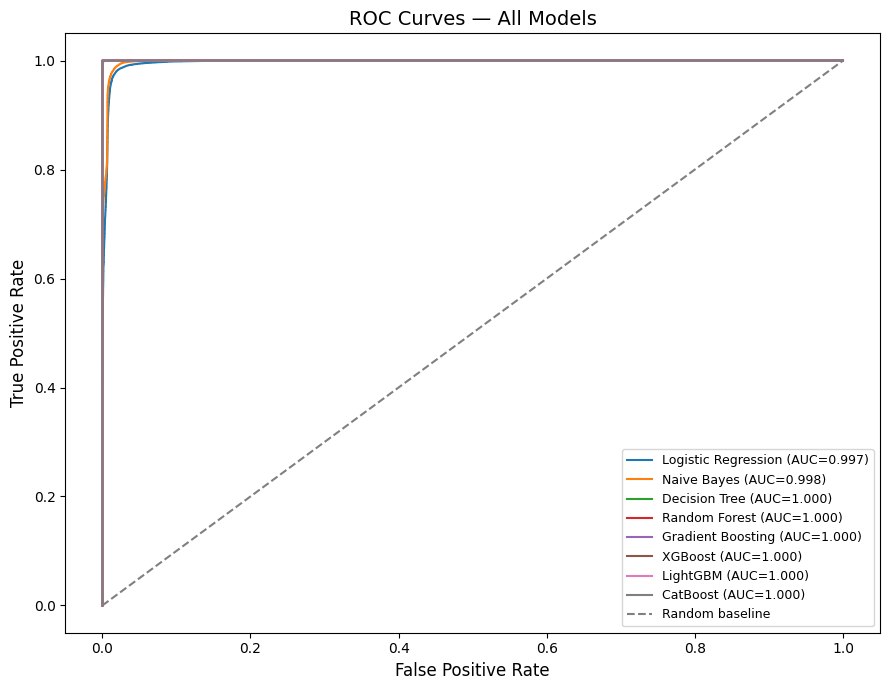

In [7]:
# ── 7. ROC Curves ─────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 7))
 
for name, v in results.items():
    fpr, tpr, _ = roc_curve(y_test, v["y_prob"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={v['ROC-AUC']:.3f})")
 
plt.plot([0, 1], [0, 1], "--", color="gray", label="Random baseline")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate",  fontsize=12)
plt.title("ROC Curves — All Models", fontsize=14)
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("/kaggle/working/roc_curves.png", dpi=150)
plt.show()
 

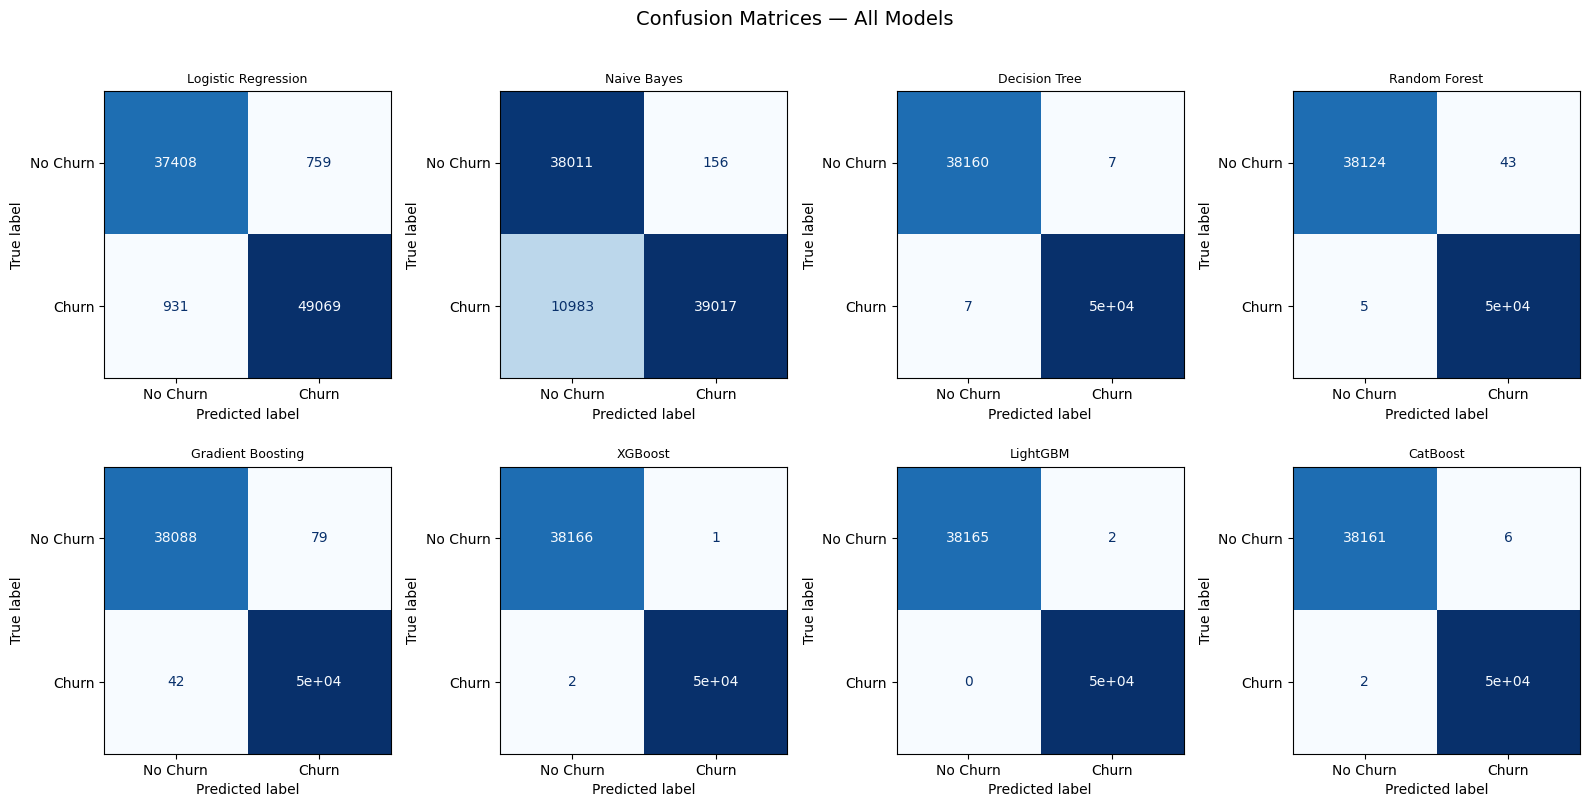

In [8]:
# ── 8. Confusion Matrices ─────────────────────────────────────────────────────
n     = len(results)
ncols = 4
nrows = -(-n // ncols)
 
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4))
axes = axes.flatten()
 
for ax, (name, v) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, v["y_pred"])
    ConfusionMatrixDisplay(
        cm, display_labels=["No Churn", "Churn"]
    ).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=9)
 
for ax in axes[n:]:
    ax.set_visible(False)
 
plt.suptitle("Confusion Matrices — All Models", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrices.png", dpi=150)
plt.show()
 


── Top 15 Features (Random Forest) ──
                        Feature  Importance
                num__CustomerID    0.533801
             num__Support Calls    0.153260
               num__Total Spend    0.097328
   cat__Contract Length_Monthly    0.058464
             num__Payment Delay    0.057241
                       num__Age    0.053360
          num__Last Interaction    0.012530
                    num__Gender    0.011179
    cat__Contract Length_Annual    0.009304
 cat__Contract Length_Quarterly    0.007842
                    num__Tenure    0.003181
           num__Usage Frequency    0.001861
   cat__Subscription Type_Basic    0.000303
cat__Subscription Type_Standard    0.000176
 cat__Subscription Type_Premium    0.000170


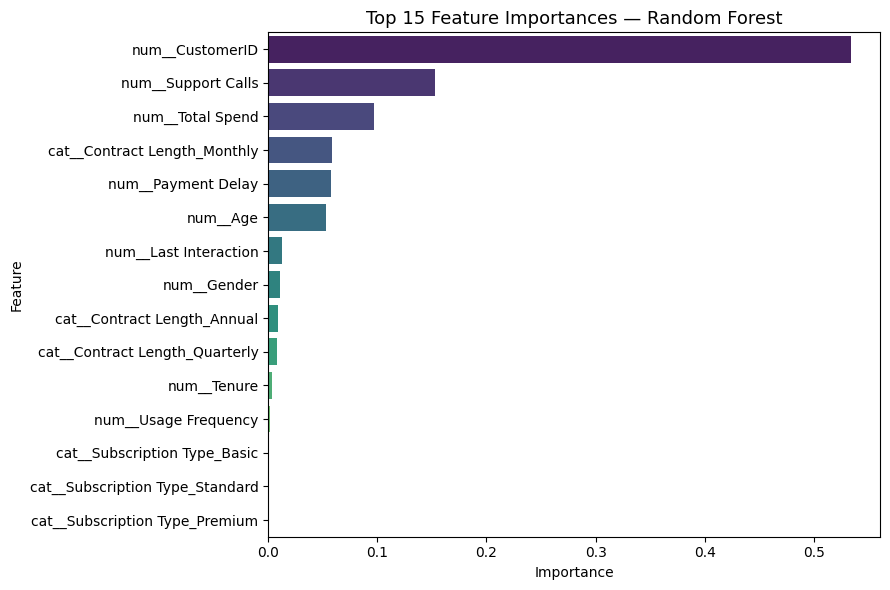

In [9]:
# ── 9. Feature Importance — Random Forest ────────────────────────────────────
if "Random Forest" in results:
    rf_pipe  = models["Random Forest"]
    prep_fit = rf_pipe.named_steps["prep"]
    rf_model = rf_pipe.named_steps["model"]
 
    feature_names = prep_fit.get_feature_names_out()
 
    feat_df = (
        pd.DataFrame({
            "Feature":    feature_names,
            "Importance": rf_model.feature_importances_,
        })
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )
 
    print("\n── Top 15 Features (Random Forest) ──")
    print(feat_df.head(15).to_string(index=False))
 
    plt.figure(figsize=(9, 6))
    sns.barplot(
        data=feat_df.head(15),
        x="Importance",
        y="Feature",
        hue="Feature",
        palette="viridis",
        legend=False,
    )
    plt.title("Top 15 Feature Importances — Random Forest", fontsize=13)
    plt.tight_layout()
    plt.savefig("/kaggle/working/feature_importance.png", dpi=150)
    plt.show()
 